In [5]:
import numpy as np
# STAGE 1: SYSTEM SPECIFICATIONS & INITIALIZATION CONSTANTS
M = 4               # Matrix Rows (Delay bins / Frequency subcarriers)
N = 4               # Matrix Columns (Doppler bins / Time slots)
Delta_f = 1000      # Subcarrier frequency spacing (1 kHz)
T = 1 / Delta_f     # Duration of a single useful time slot window (1 ms)
N_CP = 2            # Cyclic Prefix sample length per slot segment
samples_per_slot = M 
oversampling_factor = 4  # Interpolation factor to simulate continuous analog voltage traces

print("--- 16-QAM OTFS HARDWARE VERIFICATION MODEL ---")
print(f"Grid Geometry: {M} Subcarriers x {N} Time Slots")
print(f"Subcarrier Bandwidth: {Delta_f} Hz | Useful Slot Boundary: {T*1000:.1f} ms\n")

--- 16-QAM OTFS HARDWARE VERIFICATION MODEL ---
Grid Geometry: 4 Subcarriers x 4 Time Slots
Subcarrier Bandwidth: 1000 Hz | Useful Slot Boundary: 1.0 ms



In [6]:
# STAGE 2: 16-QAM GRAY CONSTELLATION MAPPING & GEOMETRIC MATRIX LOADING
# Total bits required for a single transmission frame = M * N * 4 bits (16-QAM)
np.random.seed(42)  # Set static seed for reproducible RTL bit-matching
total_bits_needed = M * N * 4
raw_bitstream = np.random.randint(0, 2, total_bits_needed)

# 16-QAM Gray Code Lookup Map (Maps bit pairs to physical coordinate scales)
gray_lut = {(0,0): -3, (0,1): -1, (1,1): +1, (1,0): +3}
nibbles = raw_bitstream.reshape(M * N, 4)
qam_symbols = []

for nibble in nibbles:
    i_coordinate = gray_lut[(nibble[0], nibble[1])]
    q_coordinate = gray_lut[(nibble[2], nibble[3])]
    qam_symbols.append(complex(i_coordinate, q_coordinate))

# Pack complex symbols row-major into the spatial Delay-Doppler Matrix D
D = np.array(qam_symbols).reshape(M, N)

##### **Stage 2: 16-QAM Gray Constellation Mapping & Geometric Matrix Loading**

This block converts a raw binary stream into complex 16-QAM symbols and packs them into the Delay-Doppler matrix `D`.

- `np.random.seed(42)` fixes the random sequence so the generated bitstream is reproducible every time the notebook runs.
- `total_bits_needed = M * N * 4` computes the exact number of bits required for one full `M x N` frame, because each 16-QAM symbol carries 4 bits.
- `raw_bitstream = np.random.randint(0, 2, total_bits_needed)` creates the test input as a flat stream of `0` and `1` values.
- `gray_lut` defines the Gray-coded amplitude levels for each bit pair. Adjacent constellation points differ by only one bit, which helps reduce bit errors under noise.
- `nibbles = raw_bitstream.reshape(M * N, 4)` groups the serial stream into 4-bit chunks, one nibble per QAM symbol.
- The `for` loop maps the first two bits to the In-Phase coordinate and the last two bits to the Quadrature coordinate, then combines them into a complex value.
- `D = np.array(qam_symbols).reshape(M, N)` stores the symbols row-by-row into the `M x N` Delay-Doppler grid so the next ISFFT stage can transform the matrix into the time-frequency domain.

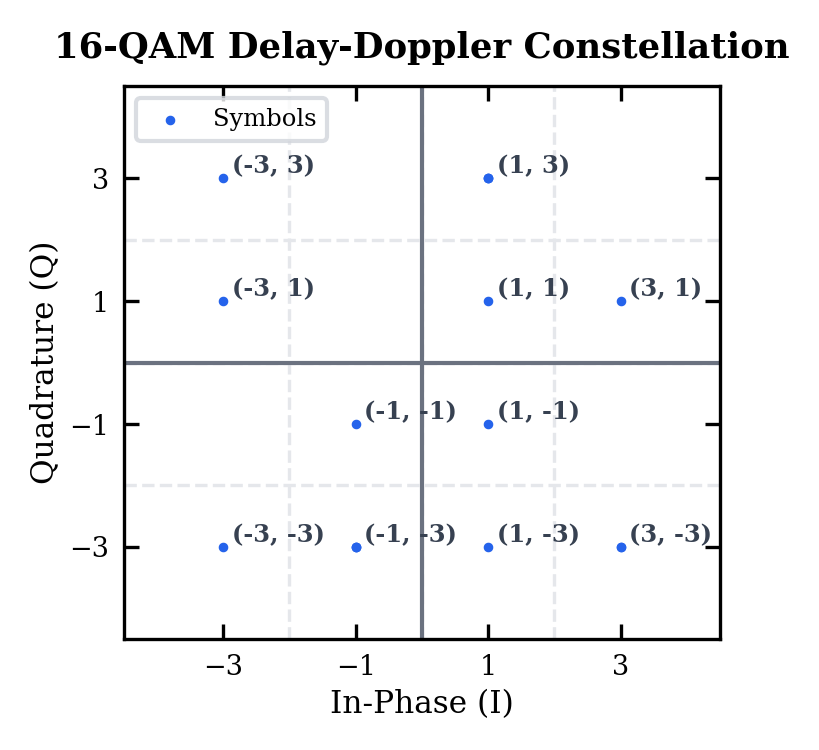

In [7]:
import matplotlib.pyplot as plt

# VISUALIZATION CHECKPOINT: COMPACT 16-QAM CONSTELLATION FOR REPORT
extracted_symbols = D.flatten()
i_coords = [s.real for s in extracted_symbols]
q_coords = [s.imag for s in extracted_symbols]

plt.figure(figsize=(2.6, 2.6), dpi=300)
plt.rcParams['font.family'] = 'serif'

# Custom gray dashed decision boundaries
for line in [-2, 0, 2]:
    plt.axvline(x=line, color='#e5e7eb', linestyle='--', linewidth=0.8, zorder=1)
    plt.axhline(y=line, color='#e5e7eb', linestyle='--', linewidth=0.8, zorder=1)

# Solid baseline coordinate axes
plt.axvline(x=0, color='#6b7280', linestyle='-', linewidth=1.0, zorder=2)
plt.axhline(y=0, color='#6b7280', linestyle='-', linewidth=1.0, zorder=2)

# Make the dots much smaller: reduce marker size to 6 and remove thick border
plt.scatter(i_coords, q_coords, color='#2563eb', 
            s=4, linewidths=0.3, marker='o', label='Symbols', zorder=3)

# Compact coordinate labels placed tightly next to the states
unique_points = list(set(zip(i_coords, q_coords)))
for (i, q) in unique_points:
    plt.text(i + 0.13, q + 0.08, f"({int(i)}, {int(q)})", 
             color='#374151', fontsize=5.8, fontweight='bold', zorder=4)

# Plot constraints and formatting configurations
ax = plt.gca()
ax.set_facecolor('white')
plt.gcf().patch.set_facecolor('white')
ax.tick_params(colors='black', labelsize=6.5, direction='in', top=True, right=True)
ax.grid(False)

# Fixed axis boundaries
plt.xlim(-4.5, 4.5)
plt.ylim(-4.5, 4.5)
plt.xticks([-3, -1, 1, 3])
plt.yticks([-3, -1, 1, 3])

# Clean, professional text framing
plt.title('16-QAM Delay-Doppler Constellation', color='black', fontsize=8.5, pad=7, fontweight='bold')
plt.xlabel('In-Phase (I)', color='black', fontsize=7.5, labelpad=2)
plt.ylabel('Quadrature (Q)', color='black', fontsize=7.5, labelpad=2)
plt.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='#d1d5db', fontsize=5.8)

plt.tight_layout()
plt.show()

In [ ]:
# STAGE 3: ISFFT DOMAIN TRANSFORMATION (THE MATRIX OPERATOR SANDWICH)
# =====================================================================
# Generate scale-normalized forward and inverse unitary transformation matrices
W_M = (1.0 / np.sqrt(M)) * np.fft.fft(np.eye(M))
W_N_inv = (1.0 / np.sqrt(N)) * np.fft.ifft(np.eye(N)) * N  # Normalized scaling factor
# Execute 2D matrix transformation to yield Time-Frequency Grid X_TF
X_TF = np.dot(np.dot(W_M, D), W_N_inv)

In [ ]:
# =====================================================================
# STAGE 4: HEISENBERG SYNTHESIS (THE HARDWARE RTL WAY)
# =====================================================================
# The discrete Heisenberg Transform applies an M-point IFFT along the 
# subcarriers (rows) of each independent time slot (columns).

# Apply unitary IFFT down the columns (axis=0). 
# np.fft.ifft divides by M, so we multiply by sqrt(M) to maintain unitary power scaling.
time_domain_slots = np.fft.ifft(X_TF, axis=0) * np.sqrt(M)

# =====================================================================
# STAGE 5: DISCRETE CYCLIC PREFIX GUARD INJECTION
# =====================================================================
# Instead of looping, we slice the tails off all 4 time slots simultaneously.
# N_CP = 2 (We copy the exact 2 discrete digital samples from the bottom of the matrix)

cp_tails = time_domain_slots[-N_CP:, :]

# Stack the copied tails directly on top of the original time slots
guarded_slots = np.vstack((cp_tails, time_domain_slots))

# =====================================================================
# STAGE 6: FPGA SERIALIZATION (PARALLEL TO SERIAL)
# =====================================================================
# The FPGA calculates a whole slot in parallel, but must push it out to the DAC
# one sample at a time, slot by slot chronologically.
# 'F' (Fortran-order) flattens the matrix column-by-column, exactly mimicking 
# the hardware shift registers pushing data to the DAC bus!

final_tx_signal = guarded_slots.flatten('F')

# --- Check the true digital sizing ---
print(f"Guarded Slot Matrix Size : {guarded_slots.shape} (6 samples x 4 slots)")
print(f"Final FPGA Digital Output: {final_tx_signal.shape} total samples heading to DAC.")

Guarded Slot Matrix Size : (6, 4) (6 samples x 4 slots)
Final FPGA Digital Output: (24,) total samples heading to DAC.


In [ ]:
# =====================================================================
# STAGE 6: PHYSICAL VOLTAGE VERIFICATION CHECKPOINTS
# =====================================================================
print("--- PIPELINE STRUCTURAL VALIDATION CHECKPOINT ---")
print(f"Delay-Doppler Input Matrix D Shape  : {D.shape}")
print(f"Time-Frequency Calendar Matrix X_TF : {X_TF.shape}")
print(f"Guarded 1D Timeline Serial Array Size: {final_tx_signal.shape[0]} samples\n")

print("First 4 Serial baseband voltages heading directly to hardware DAC registers:")
for idx in range(4):
    v_real = final_tx_signal[idx].real
    v_imag = final_tx_signal[idx].imag
    print(f" Sample s[{idx:02d}]: In-Phase (I-Channel Volts) = {v_real:6.3f} V | Quadrature (Q-Channel Volts) = {v_imag:6.3f} V")

--- PIPELINE STRUCTURAL VALIDATION CHECKPOINT ---
Delay-Doppler Input Matrix D Shape  : (4, 4)
Time-Frequency Calendar Matrix X_TF : (4, 4)
Guarded 1D Timeline Serial Array Size: 24 samples

First 4 Serial baseband voltages heading directly to hardware DAC registers:
 Sample s[00]: In-Phase (I-Channel Volts) =  1.000 V | Quadrature (Q-Channel Volts) =  2.000 V
 Sample s[01]: In-Phase (I-Channel Volts) =  0.000 V | Quadrature (Q-Channel Volts) = -4.000 V
 Sample s[02]: In-Phase (I-Channel Volts) = -3.000 V | Quadrature (Q-Channel Volts) = -3.000 V
 Sample s[03]: In-Phase (I-Channel Volts) =  3.000 V | Quadrature (Q-Channel Volts) =  1.000 V


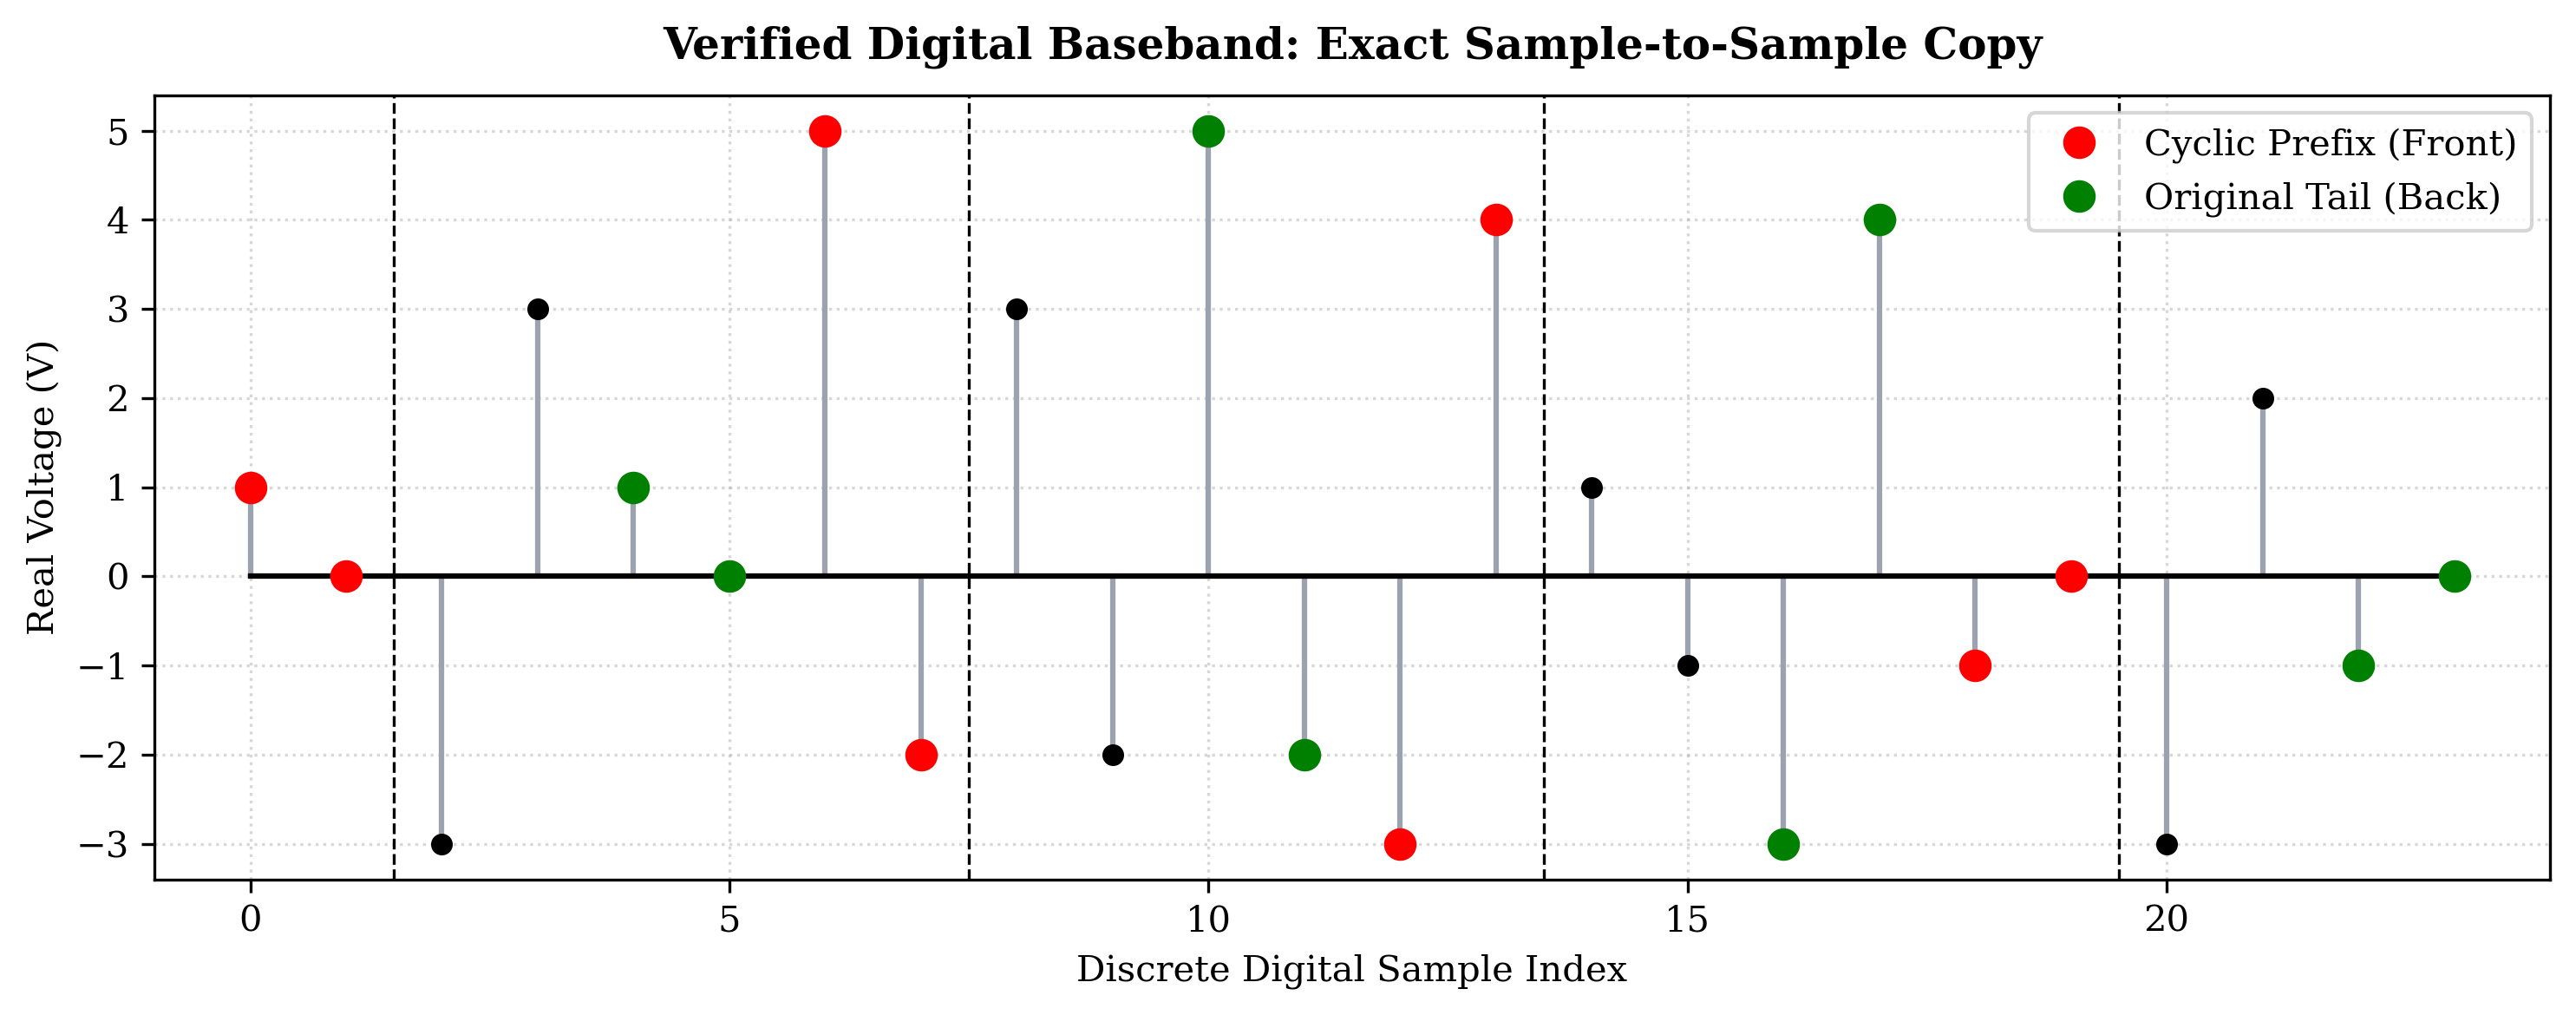

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================================
# THE TRUE DISCRETE VISUALIZATION (NO CONTINUOUS LINES)
# =====================================================================
# Extract the real voltage values from your array
discrete_voltage = final_tx_signal.real

plt.figure(figsize=(10, 4), dpi=300)
plt.rcParams['font.family'] = 'serif'

# Use a STEM plot to show actual discrete digital samples, not continuous lines
markerline, stemlines, baseline = plt.stem(discrete_voltage, basefmt="black", 
                                           linefmt='#9ca3af', markerfmt='ko')
plt.setp(markerline, markersize=5)

samples_per_guarded_slot = samples_per_slot + N_CP

# Highlight the exact discrete points without drawing continuous box spans
for slot_idx in range(N):
    start_idx = slot_idx * samples_per_guarded_slot
    
    # Highlight CP Points (Red)
    cp_indices = np.arange(start_idx, start_idx + N_CP)
    plt.plot(cp_indices, discrete_voltage[cp_indices], 'ro', markersize=8, label='Cyclic Prefix (Front)' if slot_idx == 0 else "")
    
    # Highlight Tail Points (Green)
    tail_indices = np.arange(start_idx + samples_per_slot, start_idx + samples_per_guarded_slot)
    plt.plot(tail_indices, discrete_voltage[tail_indices], 'go', markersize=8, label='Original Tail (Back)' if slot_idx == 0 else "")
    
    # Boundary line where useful data starts
    plt.axvline(x=start_idx + N_CP - 0.5, color='black', linestyle='--', linewidth=0.8)

plt.title('Verified Digital Baseband: Exact Sample-to-Sample Copy', fontweight='bold', pad=10)
plt.xlabel('Discrete Digital Sample Index', fontsize=10)
plt.ylabel('Real Voltage (V)', fontsize=10)
plt.xlim(-1, len(discrete_voltage))
plt.legend(loc='upper right', frameon=True)
plt.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

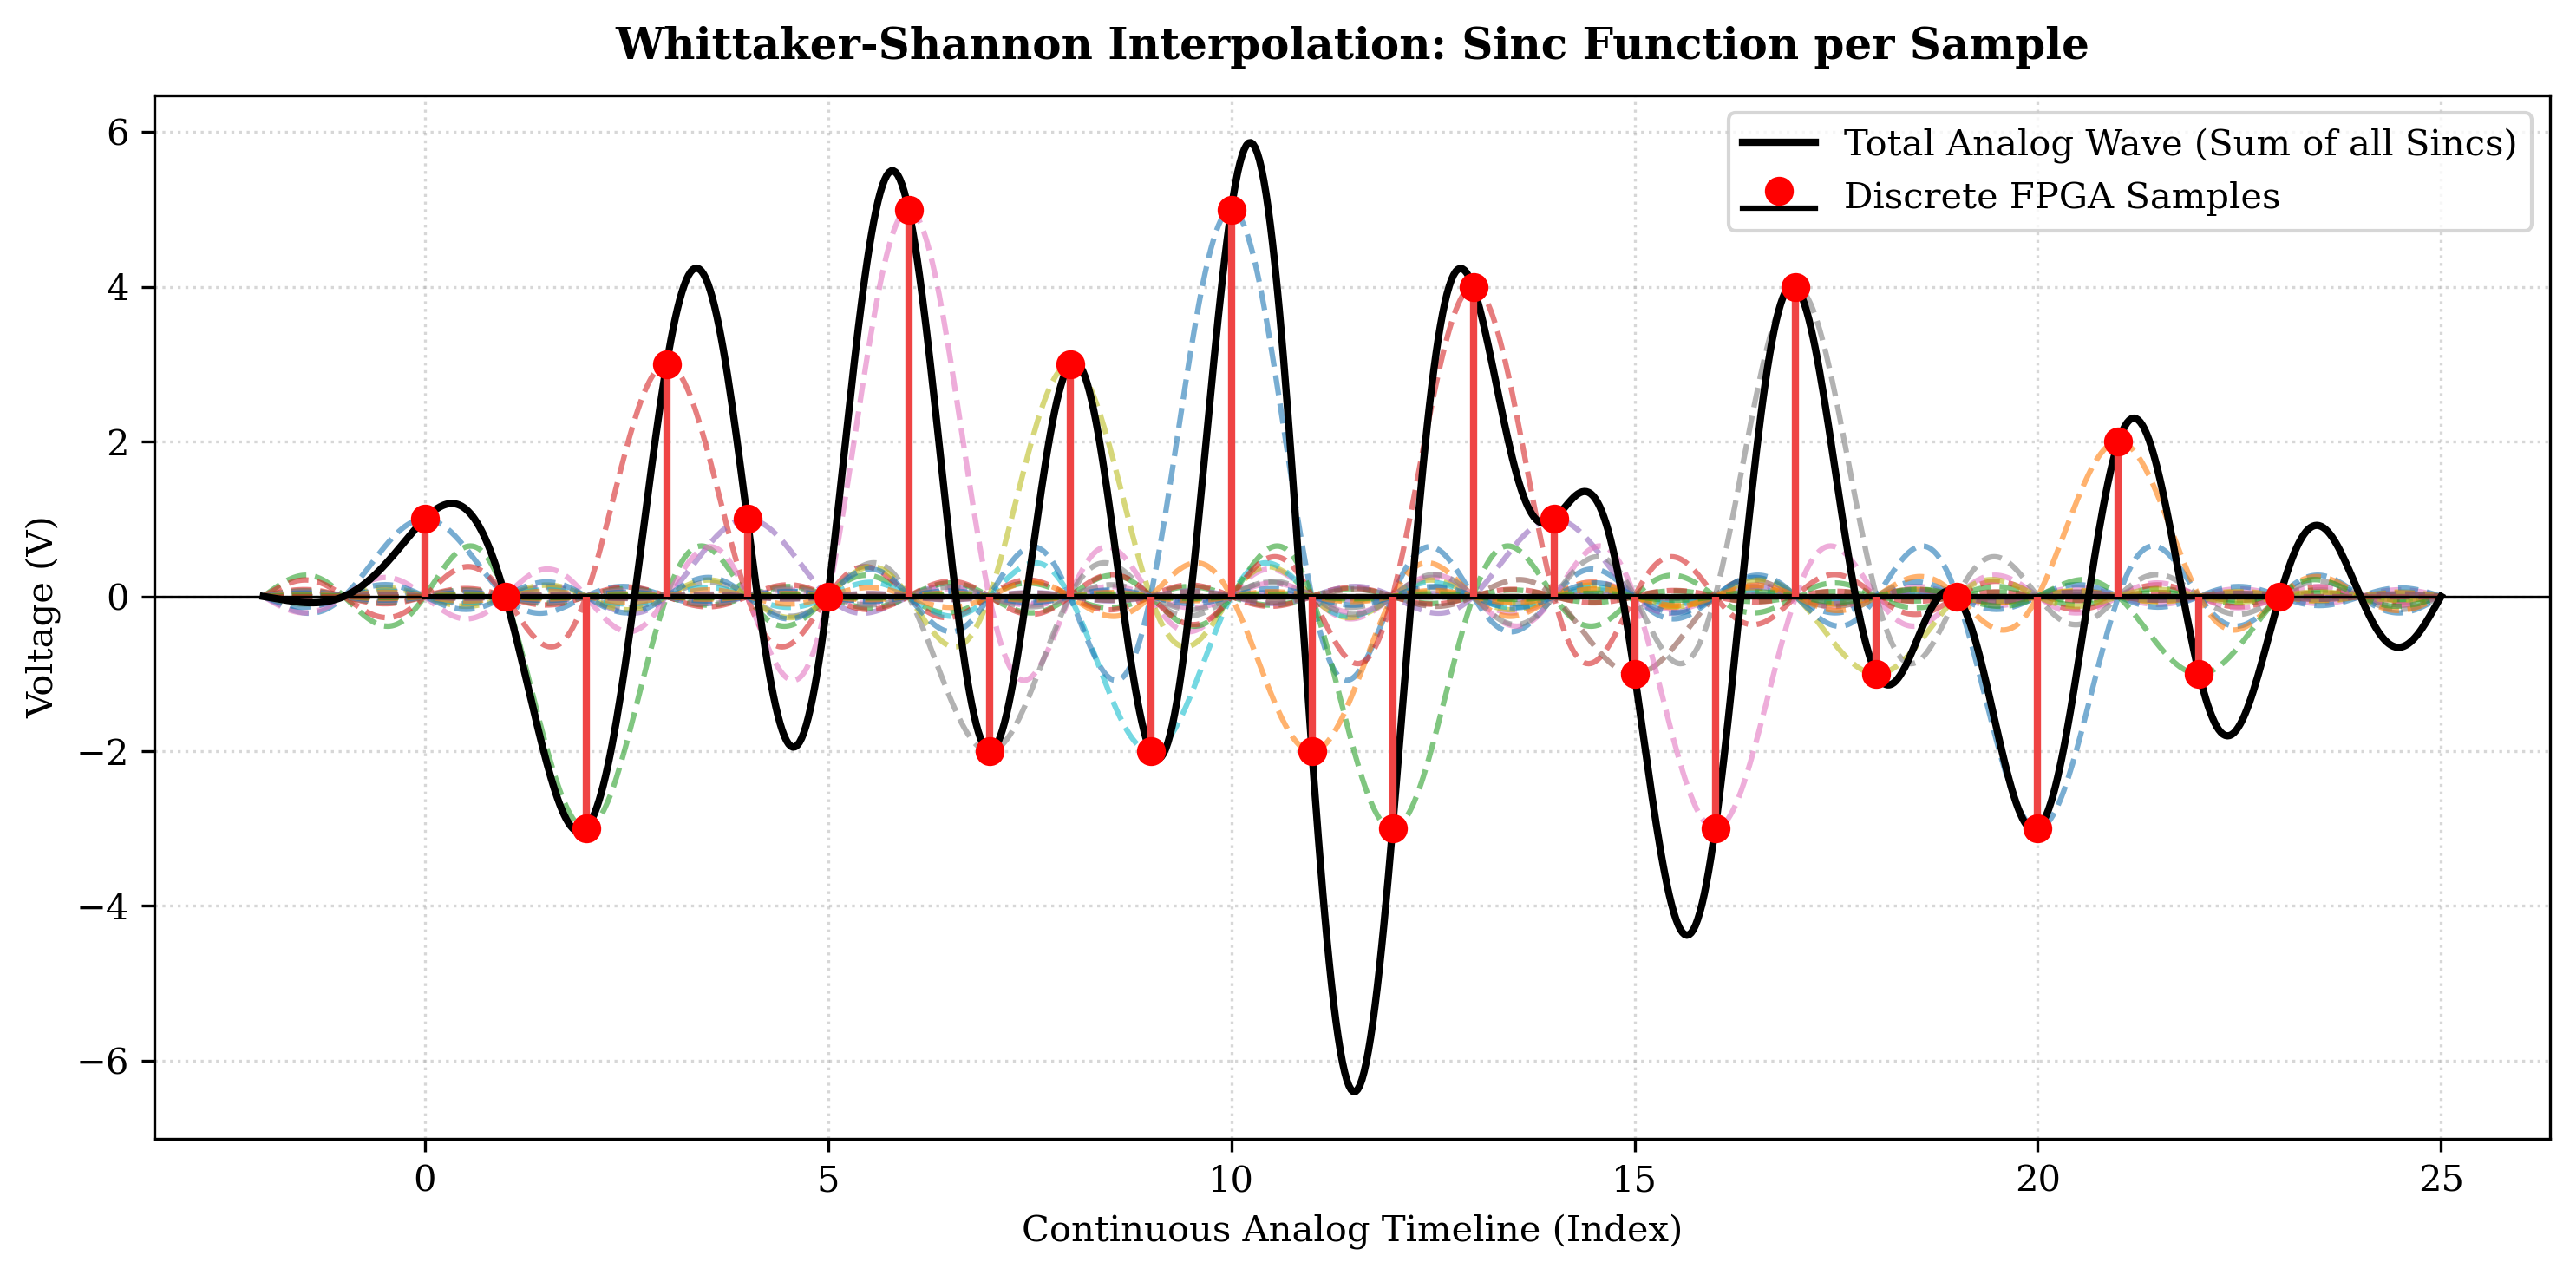

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================================
# ISOLATE A SMALL DATA CHUNK FOR VISIBILITY
# =====================================================================
# Let's take the first 6 samples (1 full time slot) from your real baseband
discrete_samples = final_tx_signal.real
sample_indices = np.arange(len(discrete_samples))

# Create a continuous, high-resolution time axis that extends a bit past the edges
# so we can see the sinc tails fading out
t_analog = np.linspace(-2, len(discrete_samples) + 1, 1000)

# Initialize the final continuous wave to zero
summed_analog_wave = np.zeros_like(t_analog)

# =====================================================================
# RENDER THE SINC OVERLAPS
# =====================================================================
plt.figure(figsize=(10, 5), dpi=300)
plt.rcParams['font.family'] = 'serif'

# 1. Loop through every single discrete sample
for n, magnitude in zip(sample_indices, discrete_samples):
    
    # Generate a continuous sinc wave centered exactly at index 'n'
    # and scaled vertically by the discrete 'magnitude'
    individual_sinc = magnitude * np.sinc(t_analog - n)
    
    # Plot this individual underlying sinc wave faintly
    plt.plot(t_analog, individual_sinc, linestyle='--', alpha=0.6)
    
    # Add it to the total physical wave
    summed_analog_wave += individual_sinc

# 2. Plot the final, total summed analog waveform
plt.plot(t_analog, summed_analog_wave, color='black', linewidth=2, label='Total Analog Wave (Sum of all Sincs)')

# 3. Plot the original discrete FPGA digital stems on top
markerline, stemlines, baseline = plt.stem(sample_indices, discrete_samples, 
                                           basefmt="black", linefmt='#ef4444', markerfmt='ro', 
                                           label='Discrete FPGA Samples')
plt.setp(markerline, markersize=7, zorder=5)
plt.setp(stemlines, linewidth=2, zorder=5)

plt.title('Whittaker-Shannon Interpolation: Sinc Function per Sample', fontweight='bold', pad=10)
plt.xlabel('Continuous Analog Timeline (Index)', fontsize=10)
plt.ylabel('Voltage (V)', fontsize=10)
plt.axhline(0, color='black', linewidth=0.8)
plt.legend(loc='upper right', frameon=True)
plt.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def save_matrix_as_latex_image(matrix, filename="matrix_output.png", matrix_name="\\mathbf{D}"):
    """
    Converts a 2D NumPy matrix into a formatted LaTeX equation string 
    and saves it directly out as a high-density PNG graphic.
    """
    # 1. Parse the complex matrix elements into formatted LaTeX string rows
    rows = []
    for row in matrix:
        row_str = []
        for element in row:
            # Format complex numbers neatly (handling zero values cleanly)
            real = int(element.real) if element.real.is_integer() else f"{element.real:.2f}"
            imag = int(element.imag) if element.imag.is_integer() else f"{element.imag:.2f}"
            
            if element.imag == 0:
                row_str.append(f"{real}")
            elif element.real == 0:
                row_str.append(f"{imag}j")
            else:
                sign = "+" if element.imag > 0 else ""
                row_str.append(f"{real}{sign}{imag}j")
                
        rows.append(" & ".join(row_str))
    
    matrix_body = " \\\\ \n".join(rows)
    
    # Construct full LaTeX math block representation using standard bmatrix brackets
    latex_string = f"${matrix_name} = \\begin{{bmatrix}} {matrix_body} \\end{{bmatrix}}$"

    print("Generated LaTeX String:")
    print(latex_string)
# =====================================================================
# EXAMPLE USAGE MATCHING YOUR DAY 4 ARRAYS
# =====================================================================
# Let's generate a dummy 4x4 matrix matching your 16-QAM elements
example_D = np.array([
    [-3+3j, -1+1j,  1-1j,  3-3j],
    [-3+1j, -1-1j,  1+1j,  3+3j],
    [-1+3j,  1+1j, -3-1j, -1-3j],
    [ 3+1j, -3-3j,  1-3j,  3-1j]
])

# Save Matrix D out to a PNG file
save_matrix_as_latex_image(D, filename="matrix_D_report.png", matrix_name="\\mathbf{D}")

Generated LaTeX String:
$\mathbf{D} = \begin{bmatrix} -1-3j & -1-3j & -1-3j & -3+3j \\ 
1+3j & 3+1j & 1+1j & 1-3j \\ 
1+3j & 3-3j & -3+1j & 1+3j \\ 
1-1j & -1-1j & 3-3j & -3-3j \end{bmatrix}$
